In [1]:
import os
os.environ['PATH'] = '/home/irman/Gelochip/.venv/bin:' + os.environ.get('PATH', '')
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, '/home/irman/Gelochip/src/gelochip')

import klayout.db as kdb
import klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, out_png=None, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs):
        print(f'GDS not found: {gds_abs}'); return
    out_png = out_png or gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True)
    lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))




2026-05-18 19:31:37.848 | WARNING  | gdsfactory.pdk:get_active_pdk:733 - No active PDK. Activating generic PDK.



2026-05-18 19:31:38.231 | INFO     | gdsfactory.technology.layer_views:__init__:790 - Importing LayerViews from YAML file: '/home/irman/Gelochip/.venv/lib/python3.13/site-packages/gdsfactory/generic_tech/layer_views.yaml'.


2026-05-18 19:31:38.232 | INFO     | gdsfactory.pdk:activate:337 - 'generic' PDK is now active


2026-05-18 19:31:38.240 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


2026-05-18 19:32:38.387 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'opamp.gds'


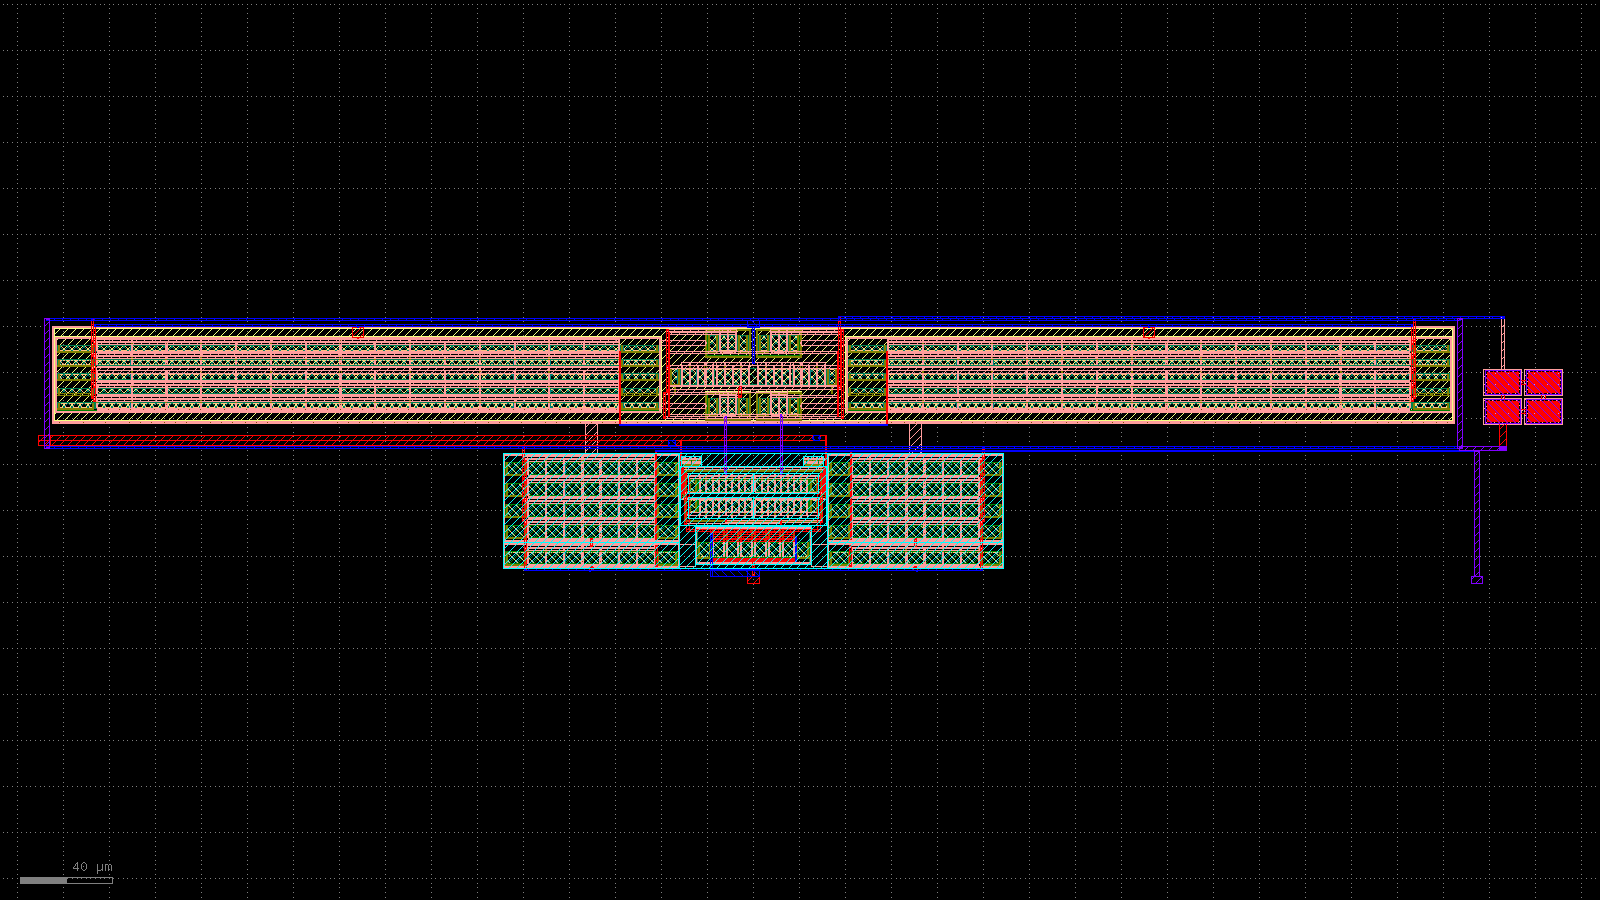

2026-05-18 19:32:38.459 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpqyxljdlh/opamp.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:32:39.603 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp2o1mrng7/opamp.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpqyxljdlh/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "opamp".
[INFO]: Loading opamp




Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "opamp".
Extracting opamp into opamp.ext

In [2]:
import sys
try:
    cm_mod = sys.modules['glayout.cells.elementary.current_mirror.current_mirror']
    if not hasattr(cm_mod, 'orig_cmn'):
        orig_cmn = cm_mod.current_mirror_netlist
        cm_mod.orig_cmn = orig_cmn
        def patched_cmn(pdk, width, length, multipliers, fingers=1, **kwargs):
            netlist = orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
            if 'B' in netlist.nodes:
                idx = netlist.nodes.index('B')
                netlist.nodes[idx] = 'VB'
            if 'VOUT' in netlist.nodes:
                idx = netlist.nodes.index('VOUT')
                netlist.nodes[idx] = 'VCOPY'
            return netlist
        cm_mod.current_mirror_netlist = patched_cmn
        for modname, mod in list(sys.modules.items()):
            if hasattr(mod, 'current_mirror_netlist'):
                setattr(mod, 'current_mirror_netlist', patched_cmn)
except Exception as e:
    pass

from gdsfactory.cell import cell, clear_cache
from gdsfactory.component import Component, copy
from gdsfactory.component_reference import ComponentReference
from gdsfactory.components.rectangle import rectangle
from glayout.pdk.mappedpdk import MappedPDK
from typing import Optional, Union
from glayout.primitives.fet import nmos, pmos, multiplier
from glayout.cells.elementary.diff_pair import diff_pair
from glayout.primitives.guardring import tapring
from glayout.primitives.mimcap import mimcap_array, mimcap
from glayout.routing.L_route import L_route
from glayout.routing.c_route import c_route
from glayout.primitives.via_gen import via_stack, via_array
from gdsfactory.routing.route_quad import route_quad
from glayout.util.comp_utils import evaluate_bbox, prec_ref_center, movex, movey, to_decimal, to_float, move, align_comp_to_port, get_padding_points_cc
from glayout.util.port_utils import rename_ports_by_orientation, rename_ports_by_list, add_ports_perimeter, print_ports, set_port_orientation, rename_component_ports
from glayout.routing.straight_route import straight_route
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.placement.two_transistor_interdigitized import two_nfet_interdigitized
from glayout.spice import Netlist

from glayout.cells.composite.opamp.opamp_twostage import opamp_twostage
from glayout.cells.elementary.current_mirror import current_mirror_netlist as orig_cmn
def patched_cmn(pdk, width, length, multipliers, fingers=1, **kwargs):
    netlist = orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
    if 'B' in netlist.nodes:
        idx = netlist.nodes.index('B')
        netlist.nodes[idx] = 'VB'
    if 'VOUT' in netlist.nodes:
        idx = netlist.nodes.index('VOUT')
        netlist.nodes[idx] = 'VCOPY'
    return netlist
current_mirror_netlist = patched_cmn
import sys
sys.modules['glayout.cells.composite.diffpair_cmirror_bias.diff_pair_cmirrorbias'].current_mirror_netlist = patched_cmn
sys.modules['glayout.cells.composite.opamp.opamp_twostage'].current_mirror_netlist = patched_cmn

def opamp_output_stage_netlist(pdk: MappedPDK, output_amp_fet_ref: ComponentReference, biasParams: list) -> Netlist:
    bias_netlist = current_mirror_netlist(pdk, width=biasParams[0], length=biasParams[1], fingers=1, multipliers=biasParams[2])

    output_stage_netlist = Netlist(
        circuit_name="OUTPUT_STAGE",
        nodes=['VDD', 'GND', 'IBIAS', 'VIN', 'VOUT']
    )

    output_stage_netlist.connect_netlist(
        output_amp_fet_ref.info['netlist'],
        [('D', 'VDD'), ('G', 'VIN'), ('B', 'GND'), ('S', 'VOUT')]
    )

    output_stage_netlist.connect_netlist(
        bias_netlist,
        [('VREF', 'IBIAS'), ('VSS', 'GND'), ('VCOPY', 'VOUT'), ('VB', 'GND')]
    )

    return output_stage_netlist

def __add_output_stage(
    pdk: MappedPDK,
    opamp_top: Component,
    amplifierParams: tuple[float, float, int],
    biasParams: list,
    rmult: int,
) -> tuple[Component, Netlist]:
    '''add output stage to opamp_top, args:
    pdk = pdk to use
    opamp_top = component to add output stage to
    amplifierParams = [width,length,fingers,mults] for amplifying FET
    biasParams = [width,length,fingers,mults] for bias FET
    '''
    # Instantiate output amplifier
    amp_fet_ref = opamp_top << nmos(
        pdk,
        width=amplifierParams[0],
        length=amplifierParams[1],
        fingers=amplifierParams[2],
        multipliers=1,
        sd_route_topmet="met3",
        gate_route_topmet="met3",
        rmult=rmult,
        with_dnwell=False,
        with_tie=True,
        with_substrate_tap=False,
        tie_layers=("met2","met2")
    )
    # Instantiate bias FET
    cmirror_ibias = opamp_top << two_nfet_interdigitized(
        pdk,
        numcols=biasParams[2],
        width=biasParams[0],
        length=biasParams[1],
        fingers=1,
        gate_route_topmet="met3",
        sd_route_topmet="met3",
        rmult=rmult,
        with_substrate_tap=False,
        tie_layers=("met2","met2")
    )

    metal_sep = pdk.util_max_metal_seperation()
    # Locate output stage relative position
    # x-coordinate: Center of SW capacitor in array
    # y-coordinate: Top of NMOS blocks
    xref_port = opamp_top.ports["mimcap_row0_col0_bottom_met_S"]
    x_cord = xref_port.center[0] - xref_port.width/2
    y_cord = opamp_top.ports["commonsource_cmirror_output_R_tie_N_top_met_N"].center[1]
    dims = evaluate_bbox(amp_fet_ref)
    center = [x_cord + dims[0]/2, y_cord - dims[1]/2]
    amp_fet_ref.move(center)
    amp_fet_ref.movey(pdk.get_grule("active_tap", "p+s/d")["min_enclosure"])
    dims = evaluate_bbox(cmirror_ibias)
    cmirror_ibias.movex(amp_fet_ref.xmin + dims[0]/2)
    cmirror_ibias.movey(amp_fet_ref.ymin - dims[1]/2 - metal_sep)
    # route input of output_stage to output of previous stage
    n_to_p_output_route = opamp_top.ports["special_con_npr_con_S"]
    opamp_top << L_route(pdk, n_to_p_output_route, amp_fet_ref.ports["multiplier_0_gate_W"])
    # route drain of amplifier to vdd
    vdd_route_extension = opamp_top.ymax-opamp_top.ports["pin_vdd_e4"].center[1]+metal_sep
    opamp_top << c_route(pdk,amp_fet_ref.ports["multiplier_0_drain_N"],set_port_orientation(opamp_top.ports["pin_vdd_e4"],"N"),width1=5,width2=5,extension=vdd_route_extension,e2glayer="met3")
    vddvia = opamp_top << via_stack(pdk,"met3","met4",fullbottom=True)
    align_comp_to_port(vddvia,opamp_top.ports["pin_vdd_e4"],('c','t'))
    # route drain of cmirror to source of amplifier
    opamp_top << c_route(pdk, cmirror_ibias.ports["B_drain_E"],amp_fet_ref.ports["multiplier_0_source_E"],extension=metal_sep)
    # route cmirror: A gate, B gate and A drain together. Then A source and B source to ground
    gate_short = opamp_top << c_route(pdk, cmirror_ibias.ports["A_gate_E"],cmirror_ibias.ports["B_gate_E"],extension=3*metal_sep,viaoffset=None)
    opamp_top << L_route(pdk, gate_short.ports["con_N"],cmirror_ibias.ports["A_drain_E"],viaoffset=False,fullbottom=False)
    srcshort = opamp_top << c_route(pdk, cmirror_ibias.ports["A_source_W"],cmirror_ibias.ports["B_source_W"],extension=metal_sep)
    opamp_top << straight_route(pdk, srcshort.ports["con_N"], cmirror_ibias.ports["welltie_N_top_met_S"],via2_alignment_layer="met2")
    # Route all tap rings together and ground them
    opamp_top << straight_route(pdk, cmirror_ibias.ports["welltie_N_top_met_N"],amp_fet_ref.ports["tie_S_top_met_S"])
    opamp_top << L_route(pdk, cmirror_ibias.ports["welltie_S_top_met_S"], opamp_top.ports["pin_gnd_E"],hwidth=4)
    # add ports, add bias/output pin, and return
    psuedo_out_port = movex(amp_fet_ref.ports["multiplier_0_source_E"].copy(),6*metal_sep)
    output_pin = opamp_top << straight_route(pdk, amp_fet_ref.ports["multiplier_0_source_E"], psuedo_out_port)
    opamp_top.add_ports(amp_fet_ref.get_ports_list(),prefix="outputstage_amp_")
    opamp_top.add_ports(cmirror_ibias.get_ports_list(),prefix="outputstage_bias_")
    opamp_top.add_ports(output_pin.get_ports_list(),prefix="pin_output_")
    bias_pin = opamp_top << rectangle(size=(5,3),layer=pdk.get_glayer("met3"),centered=True)
    bias_pin.movex(cmirror_ibias.center[0]).movey(cmirror_ibias.ports["B_gate_S"].center[1]-bias_pin.ymax-5*metal_sep)
    opamp_top << straight_route(pdk, bias_pin.ports["e2"], cmirror_ibias.ports["B_gate_S"],width=1)
    opamp_top.add_ports(bias_pin.get_ports_list(),prefix="pin_outputibias_")

    output_stage_netlist = opamp_output_stage_netlist(pdk, amp_fet_ref, biasParams)
    return opamp_top, output_stage_netlist

def opamp_netlist(two_stage_netlist: Netlist, output_stage_netlist: Netlist) -> Netlist:
    top_level_netlist = Netlist(
        circuit_name="opamp",
        nodes=["CSoutput", "vdd", "plus", "minus", "commonsourceibias", "outputibias", "diffpairibias", "gnd", "output"]
    )

    top_level_netlist.connect_netlist(
        two_stage_netlist,
        [('VDD', 'vdd'), ('GND', 'gnd'), ('DIFFPAIR_BIAS', 'diffpairibias'), ('VP', 'plus'), ('VN', 'minus'), ('CS_BIAS', 'commonsourceibias'), ('VOUT', 'CSoutput')]
    )

    top_level_netlist.connect_netlist(
        output_stage_netlist,
        [('VDD', 'vdd'), ('GND', 'gnd'), ('IBIAS', 'outputibias'), ('VIN', 'CSoutput'), ('VOUT', 'output')]
    )

    return top_level_netlist

@cell
def opamp(
    pdk: MappedPDK,
    half_diffpair_params: tuple[float, float, int] = (4.830253286815493,2.2539578478046662,8),
    diffpair_bias: tuple[float, float, int] = (6.037515802496237,4.123786739228095,3),
    half_common_source_params: tuple[float, float, int, int] = (2.0125794375155603,14.565564649657246,15,5),
    half_common_source_bias: tuple[float, float, int, int] = (4.944937663219363,7.28342012411769,7,4),
    output_stage_params: tuple[float, float, int] = (5.399091728093639,4.5857715613487375,20),
    output_stage_bias: tuple[float, float, int] = (4.833064927880735,3.4385982794948085,5),
    half_pload: tuple[float,float,int] = (6.475062736253839,2.8421424334962415,2),
    mim_cap_size=(15.335314270645531,10.161949416053947),
    mim_cap_rows=2,
    rmult: int = 2,
    with_antenna_diode_on_diffinputs: int=7, 
    add_output_stage: Optional[bool] = False
) -> Component:
    """
    create a two stage opamp with an output buffer, args->
    pdk: pdk to use
    half_diffpair_params: diffpair (width,length,fingers)
    diffpair_bias: bias transistor for diffpair nmos (width,length,fingers). The ref and output of the cmirror are identical
    half_common_source_params: pmos top component amp (width,length,fingers,mults)
    half_common_source_bias: bottom L/R large nmos current mirror (width,length,fingers,mults). The ref of the cmirror always has 1 multplier. multiplier must be >=2
    ****NOTE: change the multiplier option to change the relative sizing of the current mirror ref/output
    output_stage_amp_params: output amplifier transistor params (width, length, fingers)
    output_stage_bias: output amplifier current mirror params (width, length, fingers). The ref and output of the cmirror are identical
    half_pload: all 4 pmos load transistors of first stage (width,length,...). The last element in the tuple is the fingers of the bottom two pmos.
    mim_cap_size: width,length of individual mim_cap
    mim_cap_rows: number of rows in the mimcap array (always 2 cols)
    rmult: routing multiplier (larger = wider routes)
    with_antenna_diode_on_diffinputs: adds antenna diodes with_antenna_diode_on_diffinputs*(1um/0.5um) on the positive and negative inputs to the opamp
    """
    opamp_top = opamp_twostage(
        pdk,
        half_diffpair_params,
        diffpair_bias,
        half_common_source_params,
        half_common_source_bias,
        half_pload,
        mim_cap_size,
        mim_cap_rows,
        rmult,
        with_antenna_diode_on_diffinputs
    )
    # add output amplfier stage
    if add_output_stage:
        opamp_top, output_stage_netlist = __add_output_stage(pdk, opamp_top, output_stage_params, output_stage_bias, rmult)
        opamp_top.info['netlist'] = opamp_netlist(opamp_top.info['netlist'], output_stage_netlist)

    # return
    return rename_ports_by_orientation(component_snap_to_grid(opamp_top))




from glayout.pdk.gf180_mapped import gf180_mapped_pdk
comp = opamp(gf180_mapped_pdk)
comp.name = 'opamp'
comp.write_gds("opamp.gds")
show_gds("opamp.gds")

# DRC with magic (graceful if magic not installed)
try:
    drc_result = gf180_mapped_pdk.drc_magic(comp, comp.name)
    print('DRC:', drc_result)
except Exception as e:
    print(f'DRC skipped: {e}')
# LVS with netgen (graceful if netgen not installed)
try:
    lvs_result = gf180_mapped_pdk.lvs_netgen(comp, comp.name)
    print('LVS:', lvs_result['result_str'])
except Exception as e:
    print(f'LVS skipped: {e}')




In [3]:
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None

if run_evaluation is not None:
    result = run_evaluation("opamp.gds", comp.name, comp)
    print(result)


--- Starting Comprehensive Evaluation for opamp ---
Cleaning up intermediate files for component 'opamp'...
  - Deleted: opamp.res.ext
  - Deleted directory: opamp_lvs_out
  - Deleted: opamp.nodes
Running verification checks (DRC, LVS)...
using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:32:42.664 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp7no0wbno/opamp.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpq69x8z8m/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "opamp".
[INFO]: Loading opamp




Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "opamp".
Extracting opamp into opamp.ext

--- Evaluation complete. Results saved to opamp_1.json ---
{'component_name': 'opamp', 'timestamp': '2026-05-18T19:33:08.340862', 'drc_lvs_fail': True, 'drc': {'status': 'fail', 'is_pass': False, 'report_path': '/home/irman/Gelochip/notebooks/datasets/opamp/opamp_drc_out/drc/opamp/opamp.rpt', 'summary': {'is_pass': False, 'total_errors': 111, 'error_details': [{'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '2.770um 53.930um 3.030um 53.990um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '3.030um 53.930um 3.570um 53.990um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '3.570um 53.930um 3.830um 53.990um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '3.830um 53.930um 4.370um 53.990um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '4.370um 53.930um 4.630um 53.990um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '4.630um 53.930um 5.170um 53.990um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '5.170um 53.930um 5.430u

In [4]:
# ── SPICE Simulation with gf180 PDK models ─────────────────────────────────
import subprocess, os, re, tempfile

_GF180_MODELS = '/home/irman/Gelochip/src/gelochip/glayout/spice/gf180_typical.spice'

class _StringNetlist:
    def __init__(self, spice_str):
        import re as _re
        self._spice = spice_str
        # Use the LAST .subckt definition (top-level circuit)
        matches = list(_re.finditer(r'\.subckt\s+(\w+)\s+(.*)', spice_str, _re.IGNORECASE))
        if matches:
            m = matches[-1]
            self.circuit_name = m.group(1)
            # Filter out parameter-style tokens (containing =)
            self.nodes = [n for n in m.group(2).split() if '=' not in n]
        else:
            self.circuit_name = 'UNKNOWN'; self.nodes = []
    def generate_netlist(self): return self._spice

def _get_netlist(comp):
    if not hasattr(comp, 'info'): return None
    nl = comp.info.get('netlist_obj')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    nl = comp.info.get('netlist')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    if isinstance(nl, str) and nl.strip(): return _StringNetlist(nl)
    return None

def _fix_spice(spice):
    spice = re.sub(r'm=\{(\d+)\}', lambda x: f'm={x.group(1)}', spice)
    # Resolve l={expr}/w={expr} parameter placeholders to defaults
    spice = re.sub(r'\bl=\{[^}]+\}', 'l=0.28', spice)
    spice = re.sub(r'\bw=\{[^}]+\}', 'w=0.28', spice)
    # Clamp l/w to gf180 minimum valid values (in µm) to stay within model bins
    def _clamp_l(m):
        try: v = float(m.group(1)); return f'l={max(v, 0.28)}'
        except: return m.group(0)
    def _clamp_w(m):
        try: v = float(m.group(1)); return f'w={max(v, 0.22)}'
        except: return m.group(0)
    spice = re.sub(r'\bl=([\d.]+)', _clamp_l, spice)
    spice = re.sub(r'\bw=([\d.]+)', _clamp_w, spice)
    # Remove mimcap lines (not in gf180 model file)
    spice = re.sub(r'^.*mimcap.*$', '* mimcap removed', spice, flags=re.MULTILINE | re.IGNORECASE)
    return spice

def _build_testbench(name, nodes, vdd=3.3):
    nmap = {}
    for n in nodes:
        u = n.upper()
        if u in ('VDD', 'AVDD', 'VCC'): nmap[n] = 'vdd'
        elif u in ('VSS', 'GND', 'AVSS'): nmap[n] = '0'
        elif u in ('VB', 'VBULK', 'BULK', 'B'): nmap[n] = '0'
        else: nmap[n] = f'n_{n.lower()}'
    lines = [f'VDD vdd 0 DC {vdd}V']
    for n in nodes:
        u, c = n.upper(), nmap[n]
        if c in ('vdd', '0'): continue
        if any(k in u for k in ('INP', 'VINP', 'VP')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.55:.3f}')
        elif any(k in u for k in ('INM', 'VINM', 'VN')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.45:.3f}')
        elif any(k in u for k in ('IBIAS','NBC_','NB_10U','NB_','BIAS','DIFFPAIR_BIAS','CS_BIAS')):
            lines.append(f'I_{n} vdd {c} DC 10u')
        elif u == 'VREF':
            lines.append(f'Iref_{n} vdd {c} DC 10u')
        elif u in ('VOUT','OUTPUT','OUT','CSOUTPUT') or u.startswith('VOUT'):
            lines.append(f'RL_{n} vdd {c} 100k')
        elif u == 'VIN':
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
        elif u == 'VGN':
            lines.append(f'V_{n} {c} 0 DC {vdd:.3f}')
        elif u == 'VGP':
            lines.append(f'V_{n} {c} 0 DC 0')
        else:
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
    inst = ' '.join(nmap[n] for n in nodes)
    lines += [f'XDUT {inst} {name}', '.op',
              '.options GMIN=1e-12 RELTOL=1e-3 ITL1=500', '.save all']
    return '\n'.join(lines)

def run_spice_gf180(comp, label=''):
    nl = _get_netlist(comp)
    if nl is None:
        print(f'No netlist in {label or "component"}.info')
        return
    spice = _fix_spice(nl.generate_netlist())
    name = nl.circuit_name
    nodes = list(nl.nodes)
    print(f'Circuit : {name}')
    print(f'Nodes   : {nodes}')
    tb = _build_testbench(name, nodes)
    full = f'* {label or name}\n.include "{_GF180_MODELS}"\n\n{spice}\n\n{tb}\n.end\n'
    with tempfile.NamedTemporaryFile(mode='w', suffix='.sp', delete=False, dir='/tmp') as f:
        f.write(full); sp = f.name
    out_f = sp + '.out'
    try:
        r = subprocess.run(['ngspice', '-b', '-o', out_f, sp],
                           capture_output=True, text=True, timeout=60)
        raw = open(out_f).read() if os.path.exists(out_f) else r.stdout + r.stderr
        print(f'\n── DC Operating Point: {label or name} ──')
        in_tbl = False
        for line in raw.split('\n'):
            l = line.strip()
            if re.match(r'node\b.*voltage', l, re.I): in_tbl = True; print(f'\n{line}')
            elif in_tbl and re.match(r'-{3,}', l): print(line)
            elif in_tbl and not l: in_tbl = False
            elif in_tbl: print(line)
        no_conv = 'no convergence' in raw.lower()
        if r.returncode == 0 and not no_conv:
            print('\n\u2713 Converged \u2013 gf180 typical corner')
        elif no_conv:
            print('\n\u26a0 No convergence')
        else:
            errs = [l for l in raw.split('\n') if 'error' in l.lower() and l.strip()]
            print(f'\n\u26a0 ngspice exit {r.returncode}')
            for e in errs[:3]: print(f'  {e}')
    except Exception as e:
        print(f'Simulation error: {e}')
    finally:
        for fn in [sp, out_f]:
            try: os.unlink(fn)
            except: pass

run_spice_gf180(comp, label='opamp')


Circuit : OPAMP_TWO_STAGE
Nodes   : ['VDD', 'GND', 'DIFFPAIR_BIAS', 'VP', 'VN', 'CS_BIAS', 'VOUT']

── DC Operating Point: opamp ──

	Node                                  Voltage
	----                                  -------
	----	-------
	xdut.x1.x1.vout                  5.963059e-09
	xdut.x1.x1.b                     7.512254e-02
	xdut.x1.wire0                    3.292622e+00
	xdut.x1.x0.x0.v1                 3.287190e+00
	xdut.x0.x1.vout                  5.963059e-09
	xdut.x0.x1.b                     7.512254e-02
	xdut.wire1                       3.268941e+00
	xdut.x0.wire0                    1.217541e+00
	xdut.wire0                       2.936837e+00
	n_vout                           3.300000e+00
	n_cs_bias                        7.926480e-01
	n_vn                             1.485000e+00
	n_vp                             1.815000e+00
	n_diffpair_bias                  7.926480e-01
	vdd                              3.300000e+00

✓ Converged – gf180 typical corner
